## Fear and Greed Index

In [1]:
import pandas as pd
import requests
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
# API URL
url = "https://api.alternative.me/fng/?limit=1000"  # Fetch up to the last 1000 days

# Fetch data
response = requests.get(url)
if response.status_code == 200:
    data = response.json()["data"]  # Extract the "data" list
    
    # Filter data only from 2024
    data_2024 = [
        {
            "date": datetime.fromtimestamp(int(entry["timestamp"])), # .strftime('%Y-%m-%d %H:%M:%S')
            "value": entry["value"],
            "classification": entry["value_classification"]
        }
        for entry in data
        if datetime.fromtimestamp(int(entry["timestamp"])).year == 2024
    ]

    # Display the filtered data
    df = pd.DataFrame(data_2024)
    df = df.sort_values(by="date", ascending=True)
    df.set_index("date", inplace=True)
    print(df)

else:
    print("Error fetching data:", response.status_code)

           value classification
date                           
2024-01-01    65          Greed
2024-01-02    71          Greed
2024-01-03    70          Greed
2024-01-04    68          Greed
2024-01-05    72          Greed
...          ...            ...
2024-12-27    74          Greed
2024-12-28    72          Greed
2024-12-29    73          Greed
2024-12-30    65          Greed
2024-12-31    64          Greed

[365 rows x 2 columns]


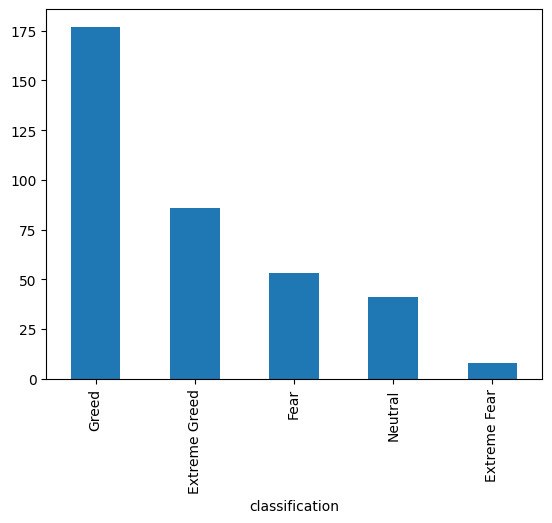

In [3]:
# Visualize the data
df['classification'].value_counts().plot(kind='bar');

In [4]:
# Save the data to a CSV file
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/4.0/fear_n_greed_2024.csv")